In [8]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

import shap

import warnings
warnings.filterwarnings("ignore")

In [9]:
# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_csv(r'C:\Users\FA23-BCS-041.CUI\Desktop\datasets\bank-additional-full.csv',
    sep=";",
    encoding="utf-8"
)

df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)

df.head()
# ==========================================================
# 3. DATA EXPLORATION
# ==========================================================

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df['y'].value_counts())

Dataset Shape: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx  

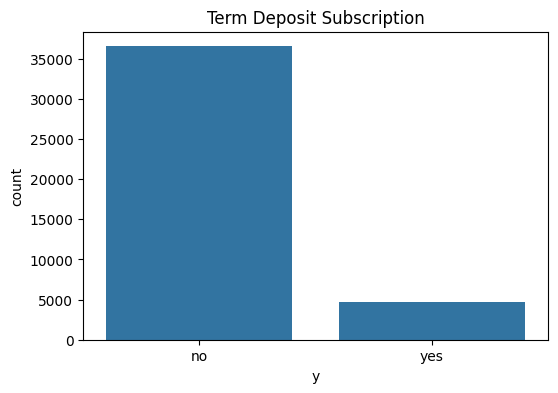

   age  job  marital  education  default  housing  loan  contact  month  \
0   56    3        1          0        0        0     0        1      6   
1   57    7        1          3        1        0     0        1      6   
2   37    7        1          3        0        2     0        1      6   
3   40    0        1          1        0        0     0        1      6   
4   56    7        1          3        0        0     2        1      6   

   day_of_week  ...  campaign  pdays  previous  poutcome  emp.var.rate  \
0            1  ...         1    999         0         1           1.1   
1            1  ...         1    999         0         1           1.1   
2            1  ...         1    999         0         1           1.1   
3            1  ...         1    999         0         1           1.1   
4            1  ...         1    999         0         1           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
0          93.994          -36.4      4.85

In [10]:
# ==========================================================
# 4. VISUALIZATION
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Term Deposit Subscription")
plt.show()
# ==========================================================
# 5. ENCODE CATEGORICAL FEATURES
# ==========================================================

df_encoded = df.copy()

label_encoders = {}

categorical_cols = df_encoded.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(df_encoded.head())
# ==========================================================
# 6. FEATURES & TARGET
# ==========================================================

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
# ==========================================================
# 7. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
# ==========================================================
# 8. FEATURE SCALING
# (ONLY FOR LOGISTIC REGRESSION)
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Model Trained
Random Forest Model Trained
===== LOGISTIC REGRESSION =====
F1 Score: 0.5193220338983051

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



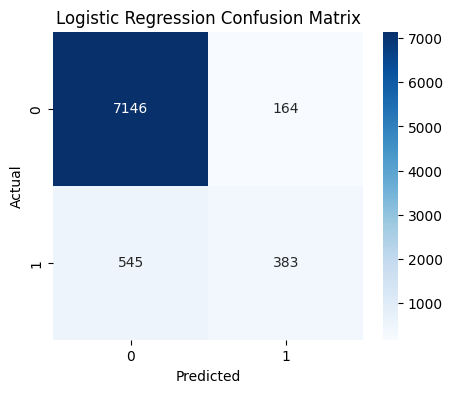

===== RANDOM FOREST =====
F1 Score: 0.6029055690072639

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7310
           1       0.69      0.54      0.60       928

    accuracy                           0.92      8238
   macro avg       0.82      0.75      0.78      8238
weighted avg       0.91      0.92      0.92      8238



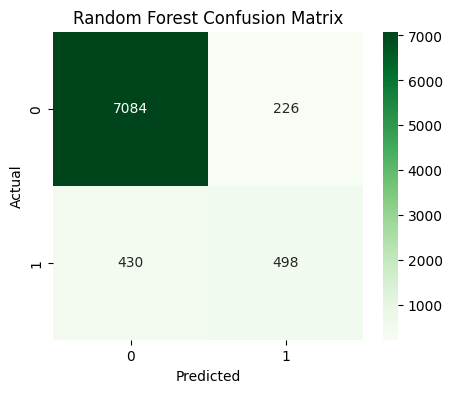

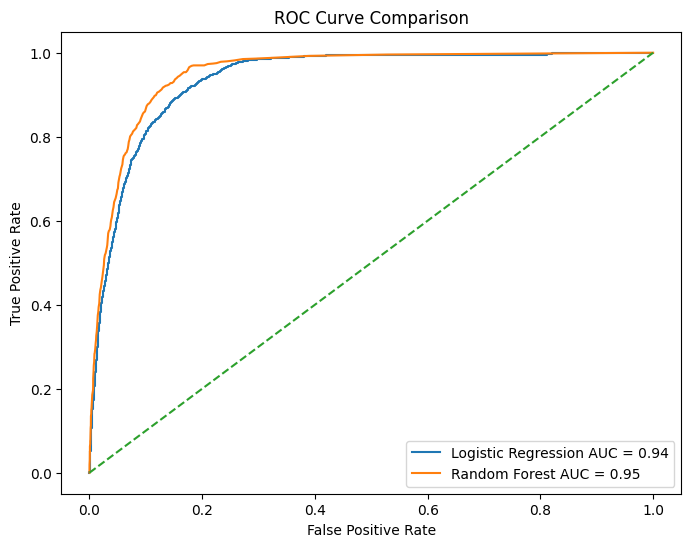

In [11]:
# ==========================================================
# 9. TRAIN LOGISTIC REGRESSION
# ==========================================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print("Logistic Regression Model Trained")
# ==========================================================
# 10. TRAIN RANDOM FOREST
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Model Trained")

# ==========================================================
# 11. MODEL EVALUATION
# ==========================================================

print("===== LOGISTIC REGRESSION =====")

print("F1 Score:",
      f1_score(y_test, lr_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_predictions
))

cm_lr = confusion_matrix(
    y_test,
    lr_predictions
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# 12. RANDOM FOREST EVALUATION
# ==========================================================

print("===== RANDOM FOREST =====")

print("F1 Score:",
      f1_score(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions
))

cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# 13. ROC CURVE
# ==========================================================

lr_probs = lr_model.predict_proba(
    X_test_scaled
)[:,1]

rf_probs = rf_model.predict_proba(
    X_test
)[:,1]

lr_auc = roc_auc_score(
    y_test,
    lr_probs
)

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    lr_probs
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression AUC = {lr_auc:.2f}'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest AUC = {rf_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:
# ==========================================================
# 14. FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.show()
# ==========================================================
# 15. SHAP EXPLAINABILITY
# ==========================================================

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

print("SHAP Ready")
# ==========================================================
# 16. SHAP SUMMARY PLOT
# ==========================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)
# ==========================================================
# 17. EXPLAIN 5 PREDICTIONS
# ==========================================================

for i in range(5):

    print(f"\nPrediction {i+1}")

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i,:,1],
            base_values=explainer.expected_value[1],
            data=X_test.iloc[i],
            feature_names=X_test.columns
        )
    )

# ==========================================================
# 18. SIMPLE PREDICTION INTERFACE
# ==========================================================

def predict_customer(index):

    customer = X_test.iloc[index]

    prediction = rf_model.predict(
        customer.values.reshape(1,-1)
    )[0]

    probability = rf_model.predict_proba(
        customer.values.reshape(1,-1)
    )[0][1]

    print("Customer Index:", index)

    if prediction == 1:
        print("Prediction: WILL SUBSCRIBE")
    else:
        print("Prediction: WILL NOT SUBSCRIBE")

    print("Probability:",
          round(probability * 100,2), "%")


predict_customer(10)

